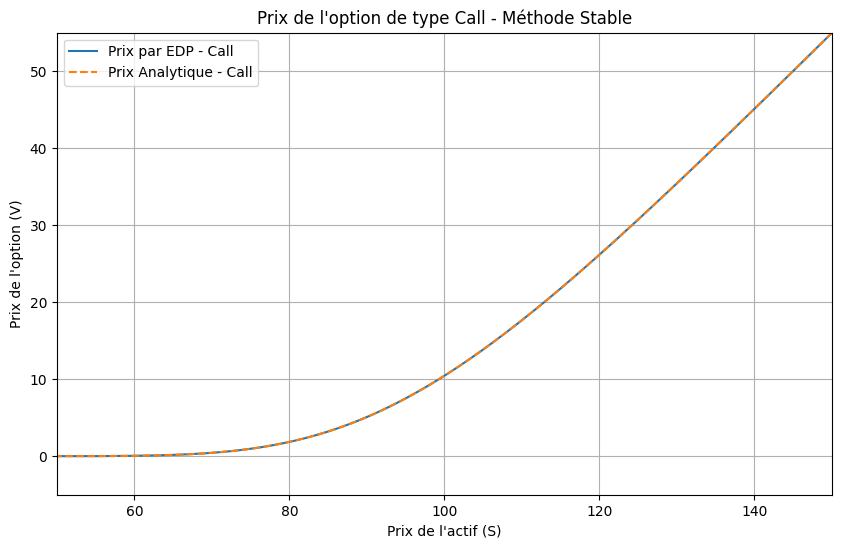

--- Résultats pour un CALL avec S0 = 100.0 ---
Prix calculé par la méthode EDP stable : 10.45098
Prix analytique de Black-Scholes      : 10.45058
Erreur absolue                          : 0.00039


In [ ]:
'''
Project 1 : Adaptative PDE solvers for option pricing
'''

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.stats import norm

# --- 1. Paramètres ---

# --- NOUVEAU : Sélecteur de type d'option ---
option_type = 'call'  # Mettre 'call' ou 'put' # <-- CHANGEMENT

# Paramètres financiers et de grille
K = 100.0
T = 1.0
r = 0.05
sigma = 0.2
N = 500
M = 500

# --- 2. Grille (inchangée) ---
x_max = np.log(K) + 5 * sigma * np.sqrt(T)
x_min = np.log(K) - 5 * sigma * np.sqrt(T)
x = np.linspace(x_min, x_max, N)
dt = T / M
dx = (x_max - x_min) / (N - 1)

# --- 3. Discrétisation (inchangée) ---
nu = r - 0.5 * sigma**2
alpha = 0.25 * dt * ((sigma**2 / dx**2) - (nu / dx))
beta = -0.5 * dt * (sigma**2 / dx**2 + r)
gamma = 0.25 * dt * ((sigma**2 / dx**2) + (nu / dx))
A_diag = np.full(N, 1 - beta)
A_upper = np.full(N - 1, -gamma)
A_lower = np.full(N - 1, -alpha)
A = np.diag(A_lower, -1) + np.diag(A_diag, 0) + np.diag(A_upper, 1)
B_diag = np.full(N, 1 + beta)
B_upper = np.full(N - 1, gamma)
B_lower = np.full(N - 1, alpha)
B = np.diag(B_lower, -1) + np.diag(B_diag, 0) + np.diag(B_upper, 1)

# --- 4. Conditions initiales et aux limites ---
S = np.exp(x)

# Payoff dépendant du type d'option # <-- CHANGEMENT
if option_type == 'call':
    V = np.maximum(S - K, 0)
elif option_type == 'put':
    V = np.maximum(K - S, 0)

# Ajustement des matrices pour les conditions aux limites
A[0, 0], A[0, 1] = 1, 0
A[-1, -1], A[-1, -2] = 1, 0
B[0, 0], B[0, 1] = 1, 0
B[-1, -1], B[-1, -2] = 1, 0

# --- 5. Itération temporelle à rebours ---
for j in range(M - 1, -1, -1):
    B_V = B @ V
    t_current = j * dt

    # Application des conditions aux limites dépendant du type d'option # <-- CHANGEMENT
    if option_type == 'call':
        B_V[0] = 0.0
        B_V[-1] = np.exp(x_max) - K * np.exp(-r * (T - t_current))
    elif option_type == 'put':
        B_V[0] = K * np.exp(-r * (T - t_current))
        B_V[-1] = 0.0

    V = np.linalg.solve(A, B_V)

# --- 6. Validation et Visualisation ---

# Fonction analytique unifiée # <-- CHANGEMENT
def black_scholes(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        price = (S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    elif option_type == 'put':
        price = (K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1))
    return price

V_analytical = black_scholes(S, K, T, r, sigma, option_type=option_type)

# Affichage dynamique # <-- CHANGEMENT
plt.figure(figsize=(10, 6))
option_type_str = option_type.capitalize()
plt.plot(S, V, label=f"Prix par EDP - {option_type_str}")
plt.plot(S, V_analytical, '--', label=f"Prix Analytique - {option_type_str}")
plt.title(f"Prix de l'option de type {option_type_str} - Méthode Stable")
plt.xlabel("Prix de l'actif (S)")
plt.ylabel("Prix de l'option (V)")
plt.grid(True)
plt.legend()
plt.xlim([K - 50, K + 50])
plt.ylim([-5, 55])
plt.show()

S0 = 100.0
option_price_at_S0 = np.interp(S0, S, V)
analytical_price_at_S0 = black_scholes(S0, K, T, r, sigma, option_type=option_type)
error = abs(option_price_at_S0 - analytical_price_at_S0)

print(f"--- Résultats pour un {option_type.upper()} avec S0 = {S0} ---")
print(f"Prix calculé par la méthode EDP stable : {option_price_at_S0:.5f}")
print(f"Prix analytique de Black-Scholes      : {analytical_price_at_S0:.5f}")
print(f"Erreur absolue                          : {error:.5f}")

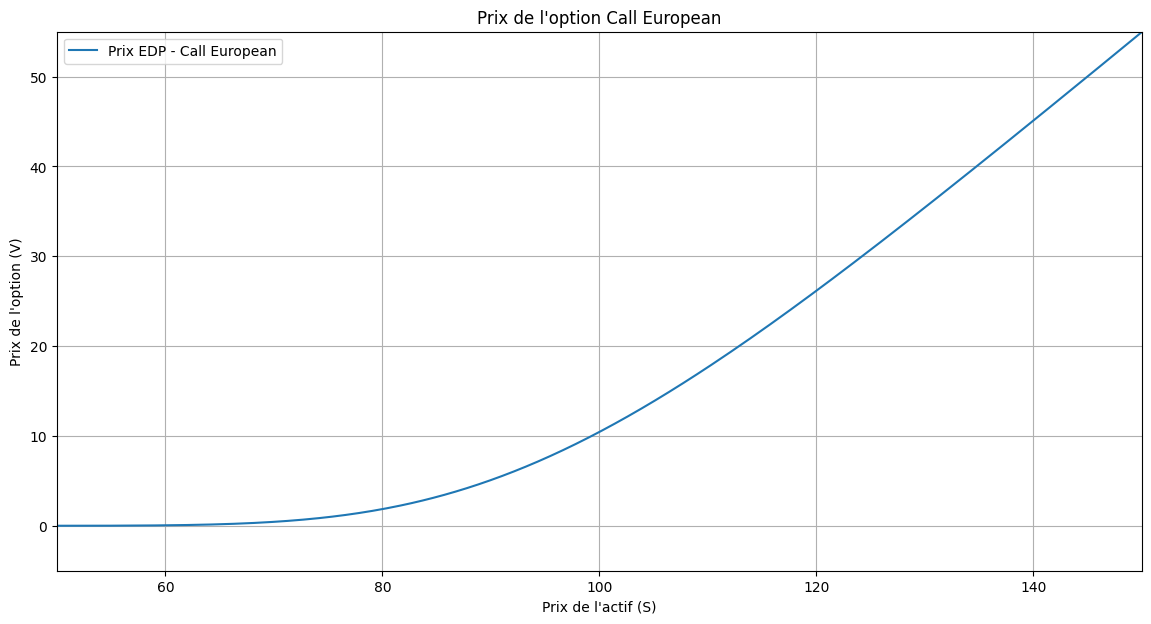

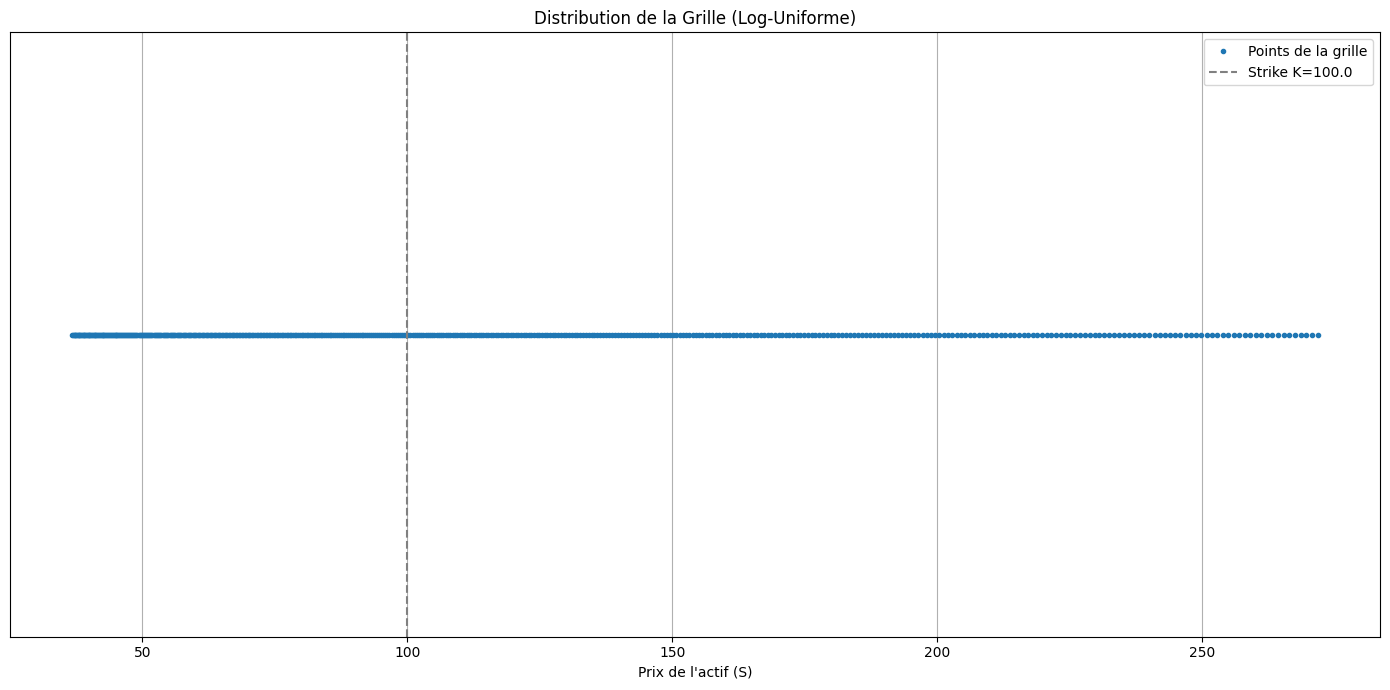

--- Résultats pour un CALL EUROPEAN avec S0 = 100.0 ---
Prix calculé par la méthode EDP : 10.45098


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. Paramètres ---
option_type = 'call'     # 'call' ou 'put'
option_style = 'european' # 'european' ou 'american'

K = 100.0
T = 1.0
r = 0.05
sigma = 0.2
N = 500
M = 1000

# --- 2. Grille (inchangée) ---
x_max = np.log(K) + 5 * sigma * np.sqrt(T)
x_min = np.log(K) - 5 * sigma * np.sqrt(T)
x = np.linspace(x_min, x_max, N)
dt = T / M
dx = (x_max - x_min) / (N - 1)
S = np.exp(x) # La grille S est non-uniforme (log-uniforme)

# --- 3. Discrétisation (inchangée) ---
nu = r - 0.5 * sigma**2
alpha = 0.25 * dt * ((sigma**2 / dx**2) - (nu / dx))
beta = -0.5 * dt * (sigma**2 / dx**2 + r)
gamma = 0.25 * dt * ((sigma**2 / dx**2) + (nu / dx))
A_diag = np.full(N, 1 - beta)
A_upper = np.full(N - 1, -gamma)
A_lower = np.full(N - 1, -alpha)
A = np.diag(A_lower, -1) + np.diag(A_diag, 0) + np.diag(A_upper, 1)
B_diag = np.full(N, 1 + beta)
B_upper = np.full(N - 1, gamma)
B_lower = np.full(N - 1, alpha)
B = np.diag(B_lower, -1) + np.diag(B_diag, 0) + np.diag(B_upper, 1)

# --- 4. Conditions initiales et aux limites (inchangée) ---
if option_type == 'call':
    V = np.maximum(S - K, 0)
elif option_type == 'put':
    V = np.maximum(K - S, 0)

A[0, 0], A[0, 1] = 1, 0
A[-1, -1], A[-1, -2] = 1, 0
B[0, 0], B[0, 1] = 1, 0
B[-1, -1], B[-1, -2] = 1, 0

# --- 5. Itération temporelle à rebours (inchangée) ---
for j in range(M - 1, -1, -1):
    B_V = B @ V
    t_current = j * dt

    if option_type == 'call':
        B_V[0] = 0.0
        B_V[-1] = np.exp(x_max) - K * np.exp(-r * (T - t_current))
    elif option_type == 'put':
        B_V[0] = K * np.exp(-r * (T - t_current))
        B_V[-1] = 0.0

    V = np.linalg.solve(A, B_V)

    if option_style == 'american':
        if option_type == 'put':
            exercise_value = np.maximum(K - S, 0)
        else: # 'call'
            exercise_value = np.maximum(S - K, 0)
        V = np.maximum(V, exercise_value)

# --- 6. Visualisation (MODIFIÉE) ---
def black_scholes(S_bs, K_bs, T_bs, r_bs, sigma_bs, option_type_bs='call'):
    d1 = (np.log(S_bs / K_bs) + (r_bs + 0.5 * sigma_bs**2) * T_bs) / (sigma_bs * np.sqrt(T_bs))
    d2 = d1 - sigma_bs * np.sqrt(T_bs)
    if option_type_bs == 'call':
        price = (S_bs * norm.cdf(d1) - K_bs * np.exp(-r_bs * T_bs) * norm.cdf(d2))
    elif option_type_bs == 'put':
        price = (K_bs * np.exp(-r_bs * T_bs) * norm.cdf(-d2) - S_bs * norm.cdf(-d1))
    return price

# Créer une figure avec deux sous-graphiques
plt.figure(figsize=(14, 7))

# Graphique 1 : Prix de l'option

style_str = option_style.capitalize()
type_str = option_type.capitalize()
plt.plot(S, V, label=f"Prix EDP - {type_str} {style_str}")

if option_style == 'american':
    V_european = black_scholes(S, K, T, r, sigma, option_type_bs=option_type)
    plt.plot(S, V_european, '--', label=f"Référence Européenne")

plt.title(f"Prix de l'option {type_str} {style_str}")
plt.xlabel("Prix de l'actif (S)")
plt.ylabel("Prix de l'option (V)")
plt.grid(True)
plt.legend()
plt.xlim([K - 50, K + 50])
plt.ylim([-5, 55])

# --- NOUVEAU : Graphique 2 : Distribution de la grille ---
plt.figure(figsize=(14, 7))
plt.plot(S, np.zeros_like(S), 'o', markersize=3, label='Points de la grille')
plt.axvline(K, color='gray', linestyle='--', label=f'Strike K={K}')
plt.title("Distribution de la Grille (Log-Uniforme)")
plt.xlabel("Prix de l'actif (S)")
plt.yticks([]) # Cacher l'axe Y
plt.grid(True)
plt.legend()

# Ajuster la mise en page et afficher
plt.tight_layout()
plt.show()

S0 = 100.0
option_price_at_S0 = np.interp(S0, S, V)
print(f"--- Résultats pour un {option_type.upper()} {style_str.upper()} avec S0 = {S0} ---")
print(f"Prix calculé par la méthode EDP : {option_price_at_S0:.5f}")

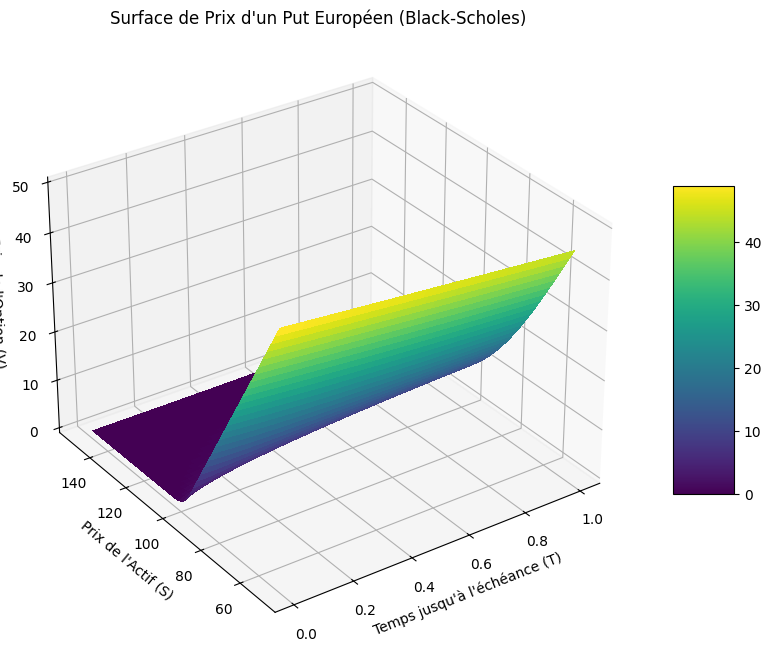

--- Prix à S0=100, T=1 an ---
Prix calculé : 7.45894


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

def black_scholes_put(S, K, T, r, sigma):
    """Calcule le prix d'un Put Européen par la formule de Black-Scholes."""
    with np.errstate(divide='ignore'):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return np.nan_to_num(price)

# --- 1. Paramètres ---
K = 100.0
r = 0.05
sigma = 0.25

# --- 2. Création de la Grille ---
# Axe des prix de l'actif
S_values = np.linspace(50, 150, 100)
# Axe du temps restant jusqu'à l'échéance
T_values = np.linspace(0.01, 1.0, 100)

# Création d'une grille 2D pour les calculs
S_grid, T_grid = np.meshgrid(S_values, T_values)

# --- 3. Calcul de la Surface de Prix ---
# On calcule le prix de l'option pour chaque point (S, T) de la grille
V_surface = black_scholes_put(S_grid, K, T_grid, r, sigma)

# --- 4. Visualisation 3D ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Tracé de la surface
surf = ax.plot_surface(T_grid, S_grid, V_surface, cmap=cm.viridis,
                       linewidth=0, antialiased=False)

# Configuration du graphique
ax.set_title("Surface de Prix d'un Put Européen (Black-Scholes)")
ax.set_xlabel("Temps jusqu'à l'échéance (T)")
ax.set_ylabel("Prix de l'Actif (S)")
ax.set_zlabel("Prix de l'Option (V)")
ax.view_init(30, -125) # Angle de vue
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

# Calcul du prix pour un point spécifique
prix_today = black_scholes_put(S=100.0, K=100.0, T=1.0, r=0.05, sigma=0.25)
print(f"--- Prix à S0=100, T=1 an ---")
print(f"Prix calculé : {prix_today:.5f}")

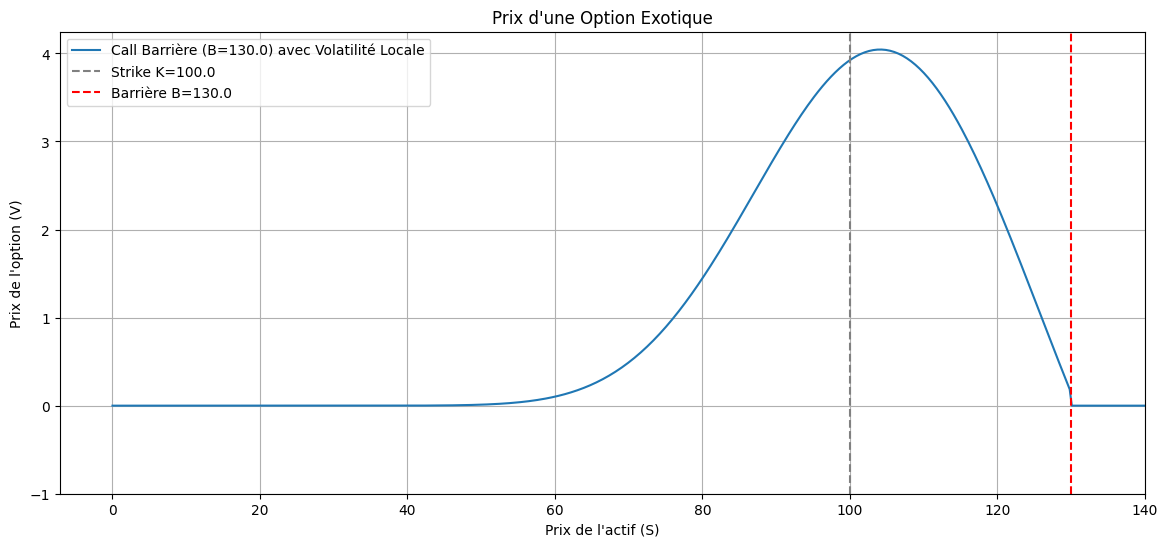

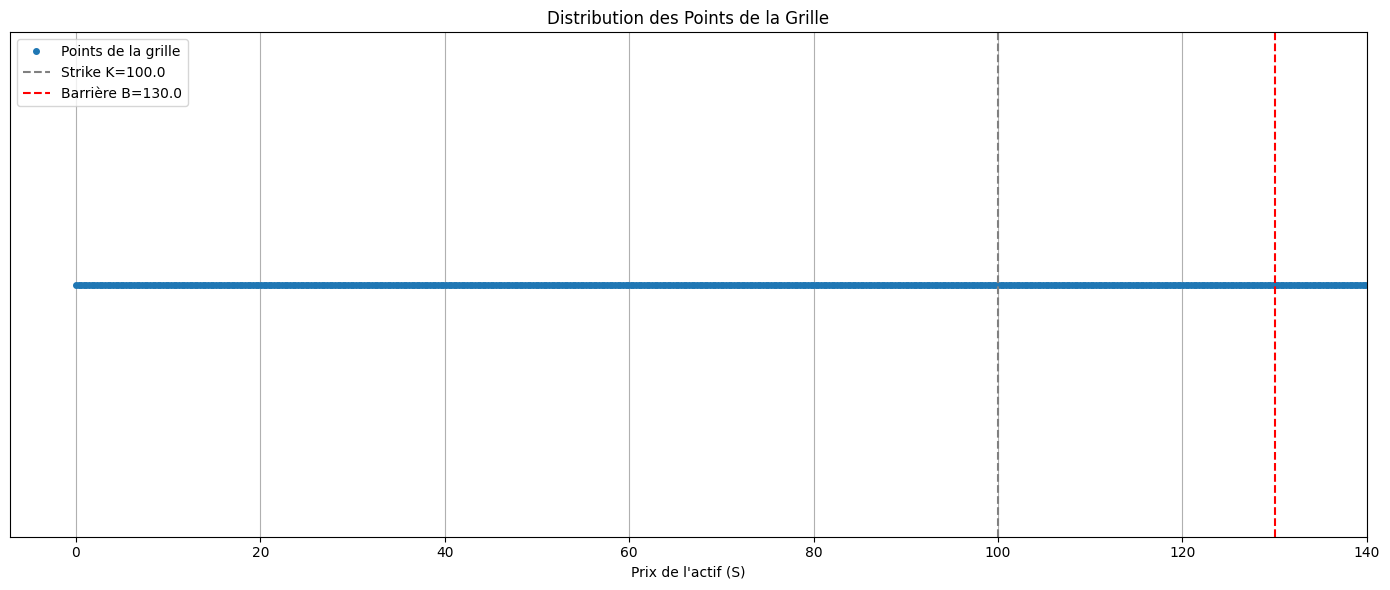

Prix calculé pour S0 = 100 : 3.9232


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres ---
K = 100.0
T = 1.0
r = 0.05
sigma_atm = 0.20
alpha = 0.4
B = 130.0

# Grille numérique
N = 500
M = 500
S_max = B * 1.1
S_min = 1e-6
S = np.linspace(S_min, S_max, N)
dt = T / M
dS = (S_max - S_min) / (N - 1)

# --- 2. Modèle de Volatilité Locale ---
def local_volatility(S, K, sigma_atm, alpha):
    return sigma_atm * (S / K)**(-alpha)
vol_grid = local_volatility(S, K, sigma_atm, alpha)

# --- 3. Initialisation ---
V = np.maximum(S - K, 0)
V[S >= B] = 0.0

# --- 4. Résolution ---
a = np.zeros(N)
b = np.zeros(N)
c = np.zeros(N)

drift = r * S[1:-1]
diffusion = 0.5 * (vol_grid[1:-1]**2) * (S[1:-1]**2)
a[1:-1] = dt * ( drift / (2 * dS) - diffusion / (dS**2) )
b[1:-1] = 1 + dt * ( 2 * diffusion / (dS**2) + r )
c[1:-1] = dt * ( -drift / (2 * dS) - diffusion / (dS**2) )

A = np.diag(b) + np.diag(a[1:], -1) + np.diag(c[:-1], 1)

A[0, 0], A[0, 1] = 1, 0
A[-1, -1], A[-1, -2] = 1, 0

for j in range(M):
    B_rhs = V.copy()
    B_rhs[0], B_rhs[-1] = 0.0, 0.0
    V = np.linalg.solve(A, B_rhs)
    V[S >= B] = 0.0

# --- 5. Visualisation ---
# Créer une figure avec deux sous-graphiques
plt.figure(figsize=(14, 6))

# Graphique 1 : Prix de l'option
plt.plot(S, V, label=f"Call Barrière (B={B}) avec Volatilité Locale")
plt.axvline(x=K, color='gray', linestyle='--', label=f'Strike K={K}')
plt.axvline(x=B, color='red', linestyle='--', label=f'Barrière B={B}')
plt.title("Prix d'une Option Exotique")
plt.xlabel("Prix de l'actif (S)")
plt.ylabel("Prix de l'option (V)")
plt.grid(True)
plt.legend()
plt.ylim(bottom=-1)
plt.xlim(right=B+10)

# --- NOUVEAU : Graphique 2 : Distribution de la grille ---
plt.figure(figsize=(14, 6))
plt.plot(S, np.zeros_like(S), 'o', markersize=4, label='Points de la grille')
plt.axvline(x=K, color='gray', linestyle='--', label=f'Strike K={K}')
plt.axvline(x=B, color='red', linestyle='--', label=f'Barrière B={B}')
plt.title("Distribution des Points de la Grille")
plt.xlabel("Prix de l'actif (S)")
plt.yticks([]) # Cacher l'axe Y qui n'est pas utile ici
plt.grid(True)
plt.legend()
plt.xlim(right=B+10)

# Ajuster la mise en page et afficher
plt.tight_layout()
plt.show()

option_price_at_100 = np.interp(100, S, V)
print(f"Prix calculé pour S0 = 100 : {option_price_at_100:.4f}")

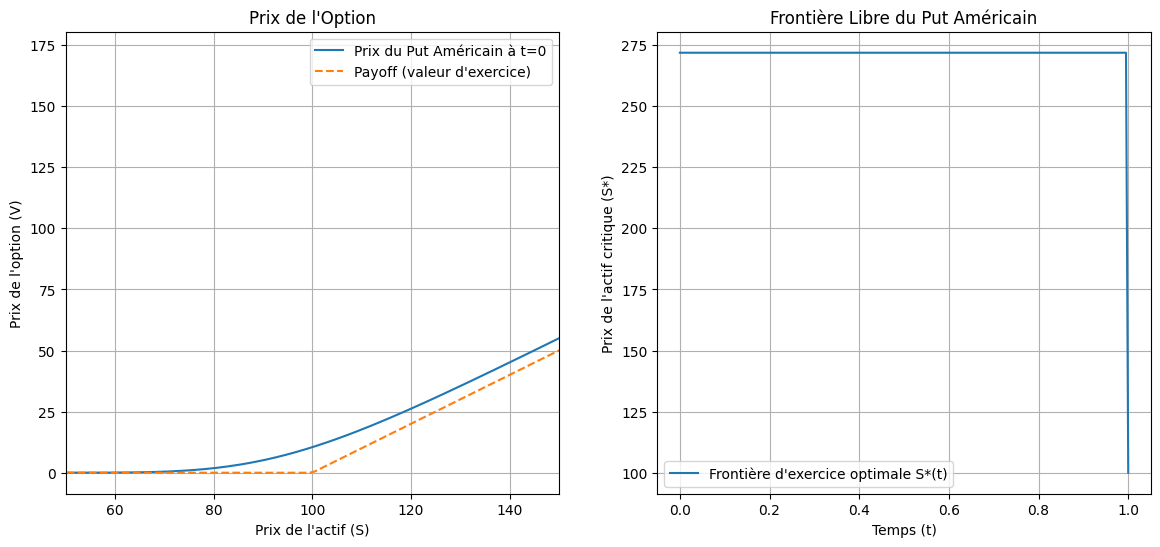

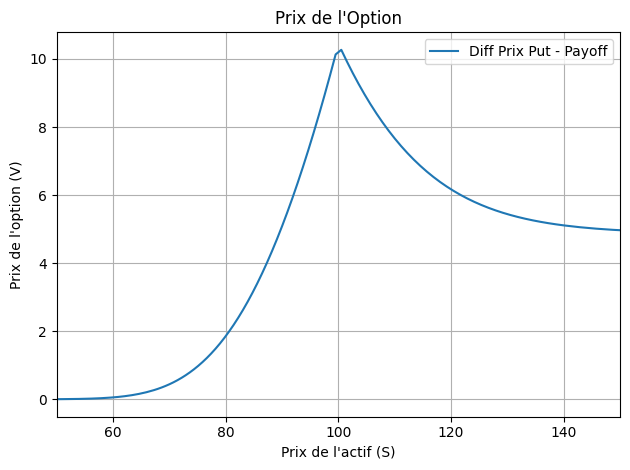

Frontière d'exercice à t=0 : 271.83
Frontière d'exercice à t=T (maturité) : 100.00


In [ ]:
'''
Project 2 : Free-boundary PDE methods for american options
'''

import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres ---
# Nous allons utiliser un Put Américain, car pour un Call sans dividende,
# l'exercice anticipé n'est jamais optimal.
option_type = 'call'
option_style = 'american'

K = 100.0
T = 1.0
r = 0.05
sigma = 0.2
N = 200 # Nombre de points de la grille de prix
M = 200 # Nombre de pas de temps

# --- 2. Grille et Discrétisation (inchangés) ---
x_max = np.log(K) + 5 * sigma * np.sqrt(T)
x_min = np.log(K) - 5 * sigma * np.sqrt(T)
x = np.linspace(x_min, x_max, N)
dt = T / M
dx = (x_max - x_min) / (N - 1)
S = np.exp(x)
nu = r - 0.5 * sigma**2
alpha = 0.25 * dt * ((sigma**2 / dx**2) - (nu / dx))
beta = -0.5 * dt * (sigma**2 / dx**2 + r)
gamma = 0.25 * dt * ((sigma**2 / dx**2) + (nu / dx))
A_diag = np.full(N, 1 - beta)
A_upper = np.full(N - 1, -gamma)
A_lower = np.full(N - 1, -alpha)
A = np.diag(A_lower, -1) + np.diag(A_diag, 0) + np.diag(A_upper, 1)
B_diag = np.full(N, 1 + beta)
B_upper = np.full(N - 1, gamma)
B_lower = np.full(N - 1, alpha)
B = np.diag(B_lower, -1) + np.diag(B_diag, 0) + np.diag(B_upper, 1)

# --- 3. Conditions initiales et aux limites ---
if option_type == 'call':
    V = np.maximum(S - K, 0)
    exercise_value = np.maximum(S - K, 0)
elif option_type == 'put':
    V = np.maximum(K - S, 0)
    exercise_value = np.maximum(K - S, 0)

A[0, 0], A[0, 1] = 1, 0
A[-1, -1], A[-1, -2] = 1, 0
B[0, 0], B[0, 1] = 1, 0
B[-1, -1], B[-1, -2] = 1, 0

# --- NOUVEAU : Tableau pour stocker la frontière libre ---
free_boundary = np.zeros(M + 1)
# À la maturité, la frontière est le strike K
free_boundary[M] = K

# --- 4. Itération temporelle à rebours ---
for j in range(M - 1, -1, -1):
    B_V = B @ V
    t_current = j * dt

    if option_type == 'put':
        B_V[0] = K * np.exp(-r * (T - t_current))
        B_V[-1] = 0.0

    V_continuation = np.linalg.solve(A, B_V)
    V = np.maximum(V_continuation, exercise_value)

    # --- NOUVEAU : Recherche et stockage de la frontière ---
    # La frontière est le premier point S où V > exercise_value (en partant de K)
    # ou le dernier point où V == exercise_value.
    # On utilise une petite tolérance pour la comparaison de nombres flottants.
    try:
        # np.isclose retourne un tableau de True/False
        # np.where trouve les indices où la condition est True
        # On prend le dernier indice [0][-1] qui correspond au S le plus élevé
        idx = np.where(np.isclose(V, exercise_value, atol=1e-8))[0][-1]
        free_boundary[j] = S[idx]
    except IndexError:
        # Si aucun point d'exercice n'est trouvé, la frontière est au bord
        free_boundary[j] = S[-1]

# --- 5. Visualisation ---
time_grid = np.linspace(0, T, M + 1)

plt.figure(figsize=(14, 6))

# Graphique 1 : Le prix de l'option à t=0
plt.subplot(1, 2, 1)
plt.plot(S, V, label="Prix du Put Américain à t=0")
plt.plot(S, exercise_value, '--', label="Payoff (valeur d'exercice)")
plt.title("Prix de l'Option")
plt.xlabel("Prix de l'actif (S)")
plt.ylabel("Prix de l'option (V)")
plt.grid(True)
plt.legend()
plt.xlim([K - 50, K + 50])

# Graphique 2 : La frontière libre
plt.subplot(1, 2, 2)
plt.plot(time_grid, free_boundary, label="Frontière d'exercice optimale S*(t)")
plt.title("Frontière Libre du Put Américain")
plt.xlabel("Temps (t)")
plt.ylabel("Prix de l'actif critique (S*)")
plt.grid(True)
plt.legend()

plt.figure()
#plt.plot(S, V, label="Prix du Put Américain à t=0")
plt.plot(S, V - exercise_value, label="Diff Prix Put - Payoff")
plt.title("Prix de l'Option")
plt.xlabel("Prix de l'actif (S)")
plt.ylabel("Prix de l'option (V)")
plt.grid(True)
plt.legend()
plt.xlim([K - 50, K + 50])

plt.tight_layout()
plt.show()

print(f"Frontière d'exercice à t=0 : {free_boundary[0]:.2f}")
print(f"Frontière d'exercice à t=T (maturité) : {free_boundary[-1]:.2f}")

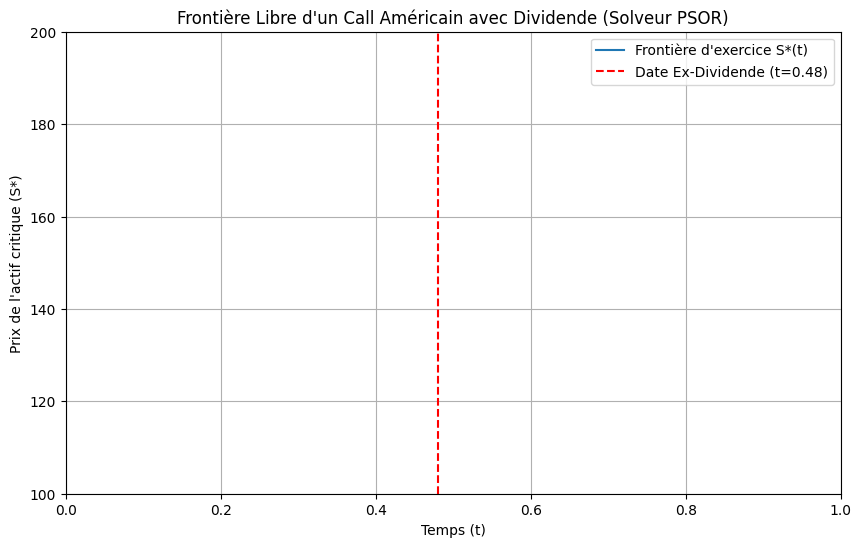

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres ---
option_type = 'call'
K = 100.0
T = 1.0
r = 0.05
sigma = 0.25
div_amount = 5.0
div_time = 0.48

# Grille numérique
N = 150  # Grille plus fine
M = 250
S_max = 200.0
S_min = 1e-5
S = np.linspace(S_min, S_max, N + 1)
dt = T / M
dS = (S_max - S_min) / N

# --- 2. Discrétisation ---
V = np.zeros((N + 1, M + 1))
exercise_value = np.maximum(S - K, 0)
V[:, M] = exercise_value
free_boundary = np.zeros(M + 1)
div_idx = int(div_time / dt)

# Coefficients pour le solveur
drift = r * S
diffusion = 0.5 * sigma**2 * S**2
a = 0.5 * dt * (diffusion / dS**2 - drift / dS)
b = 1 - dt * (diffusion / dS**2 * 2 + r)
c = 0.5 * dt * (diffusion / dS**2 + drift / dS)

# Paramètres du solveur PSOR
omega = 1.5  # Facteur de relaxation
tol = 1e-5   # Tolérance de convergence

# --- 3. Résolution à Rebours avec PSOR ---
for j in range(M - 1, -1, -1):
    V_old = V[:, j+1]

    # --- AJUSTEMENT POUR DIVIDENDE ---
    if j + 1 == div_idx:
        S_after_div = S - div_amount
        V_old = np.interp(S_after_div, S, V_old)

    V_new = V_old.copy() # Estimation initiale

    # --- BOUCLE ITÉRATIVE DU SOLVEUR PSOR ---
    for it in range(5000): # Max iterations
        V_last_iter = V_new.copy()
        for i in range(1, N): # Pour chaque point intérieur de la grille S
            # Mise à jour itérative
            val = a[i] * V_new[i-1] + b[i] * V_old[i] + c[i] * V_new[i+1]
            V_new[i] = (1 - omega) * V_last_iter[i] + omega * val

        # Application de la condition d'exercice (la "Projection")
        V_new = np.maximum(V_new, exercise_value)

        # Vérification de la convergence
        if np.max(np.abs(V_new - V_last_iter)) < tol:
            break

    V[:, j] = V_new

    # Stockage de la frontière libre
    try:
        idx = np.where(np.abs(V[:, j] - exercise_value) < tol)[0][0]
        free_boundary[j] = S[idx]
    except IndexError:
        free_boundary[j] = S_max

# --- 4. Visualisation ---
plt.figure(figsize=(10, 6))
plt.plot(t, free_boundary, label="Frontière d'exercice S*(t)")
plt.axvline(div_time, color='red', linestyle='--', label=f'Date Ex-Dividende (t={div_time})')
plt.title("Frontière Libre d'un Call Américain avec Dividende (Solveur PSOR)")
plt.xlabel("Temps (t)")
plt.ylabel("Prix de l'actif critique (S*)")
plt.ylim(K, S_max)
plt.xlim(0, T)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
'''
Project 3 : Mixed-integer optimization for portfolio selection
Quadratic function solver version
'''


import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# --- 1. Paramètres et Données de Marché Simulées ---

# Nombre d'actifs disponibles
n = 10

# Données simulées (dans un cas réel, on utiliserait des données historiques)
np.random.seed(0)
mu = np.abs(np.random.randn(n, 1)) / 10  # Rendements attendus
Sigma = np.random.randn(n, n)
Sigma = Sigma.T @ Sigma / 10 # Matrice de covariance

# --- 2. Contraintes du Monde Réel ---

R_target = 0.05       # Rendement annuel cible du portefeuille
K_max = 5             # Nombre maximum d'actifs dans le portefeuille
w_min = 0.10          # Poids minimum si un actif est sélectionné

# --- 3. Formulation du Problème d'Optimisation avec CVXPY ---

# Définition des variables
w = cp.Variable(n)                    # Poids continus
y = cp.Variable(n, boolean=True)      # Variables de décision binaires (0 ou 1)

# Définition de la fonction objectif : minimiser la variance
objective = cp.Minimize(cp.quad_form(w, Sigma))

# Définition des contraintes
constraints = [
    # Contraintes de base de Markowitz
    cp.sum(w) == 1,
    w >= 0,
    w.T @ mu >= R_target,

    # Contraintes mixtes (entières/continues)
    # 1. Contrainte de cardinalité
    cp.sum(y) <= K_max,

    # 2. Contraintes de poids minimum et lien entre w et y
    w <= y,          # Si y_i=0, w_i=0. Si y_i=1, w_i<=1
    w >= w_min * y   # Si y_i=1, w_i>=w_min
]

# Création et résolution du problème
problem = cp.Problem(objective, constraints)

# On doit utiliser un solveur qui gère les problèmes mixtes, comme CBC (inclus dans cvxpy)
# Si vous avez des solveurs commerciaux comme Gurobi ou Mosek, ils sont plus performants.
problem.solve(solver=cp.CBC, verbose=False)
#problem.solve(solver=cp.GLPK_MI, verbose=False)

# --- 4. Analyse des Résultats ---

print(f"Statut de la solution : {problem.status}")

if problem.status == 'optimal' or problem.status == 'optimal_inaccurate':
    # Récupération des poids optimaux
    w_optimal = w.value

    print("\n--- Portefeuille Optimal Construit ---")

    # Affichage des poids
    assets = [f'Actif {i+1}' for i in range(n)]
    for i, weight in enumerate(w_optimal):
        if weight > 1e-6: # Afficher seulement les actifs sélectionnés
            print(f"{assets[i]}: {weight*100:.2f}%")

    # Vérification des contraintes
    num_assets = np.sum(w_optimal > 1e-6)
    print(f"\nNombre d'actifs dans le portefeuille : {num_assets} (Contrainte <= {K_max})")

    portfolio_return = w_optimal.T @ mu
    portfolio_risk = np.sqrt(w_optimal.T @ Sigma @ w_optimal)
    print(f"Rendement attendu : {portfolio_return[0]*100:.2f}% (Cible >= {R_target*100:.2f}%)")
    print(f"Risque (écart-type) : {portfolio_risk*100:.2f}%")

    # Visualisation
    plt.figure(figsize=(10, 6))
    plt.bar(assets, w_optimal * 100)
    plt.title("Allocation Optimale du Portefeuille (avec contraintes réelles)")
    plt.ylabel("Poids (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Le problème d'optimisation n'a pas pu être résolu.")

SolverError: The solver CBC is not installed.

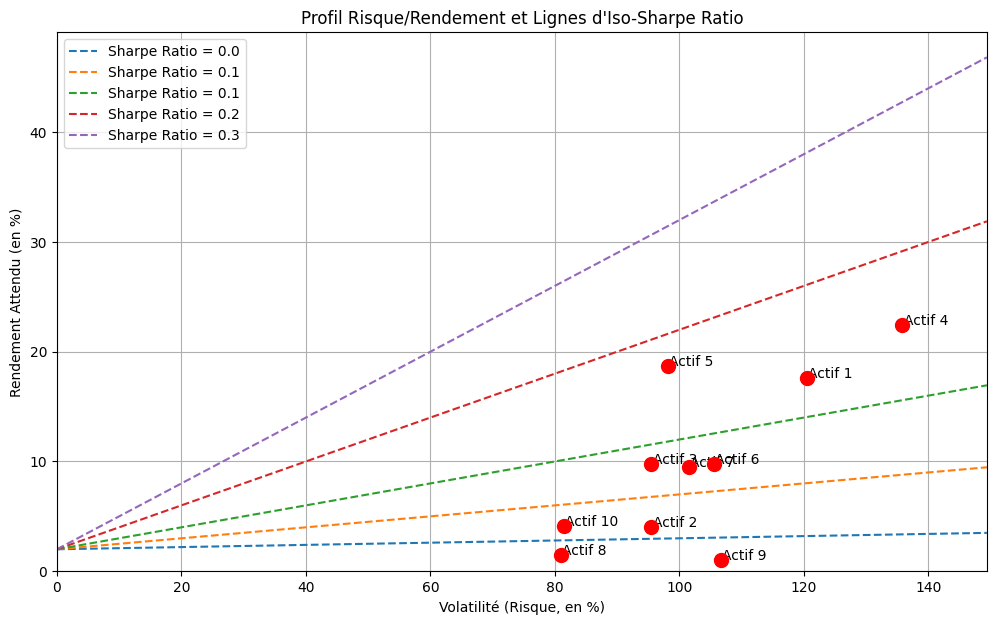

--- Analyse du Portefeuille de Référence (Poids Égaux 1/N) ---
Rendement attendu : 9.84%
Risque/Volatilité : 37.46%
Sharpe Ratio      : 0.21
--------------------------------------------------
--- Analyse du Portefeuille (Sélection par Sharpe Ratio) ---
Actifs sélectionnés : ['Actif 7', 'Actif 3', 'Actif 1', 'Actif 4', 'Actif 5']
Rendement attendu : 15.60%
Risque/Volatilité : 44.06%
Sharpe Ratio      : 0.31
--------------------------------------------------

--- Portefeuille Optimal Construit (avec Scipy) ---
Actif 1: 26.20%
Actif 4: 10.00%
Actif 5: 32.21%
Actif 8: 21.60%
Actif 10: 10.00%

Nombre d'actifs dans le portefeuille : 5
Rendement attendu : 13.61%
Risque (écart-type) : 22.50%
Sharpe Ratio      : 0.52


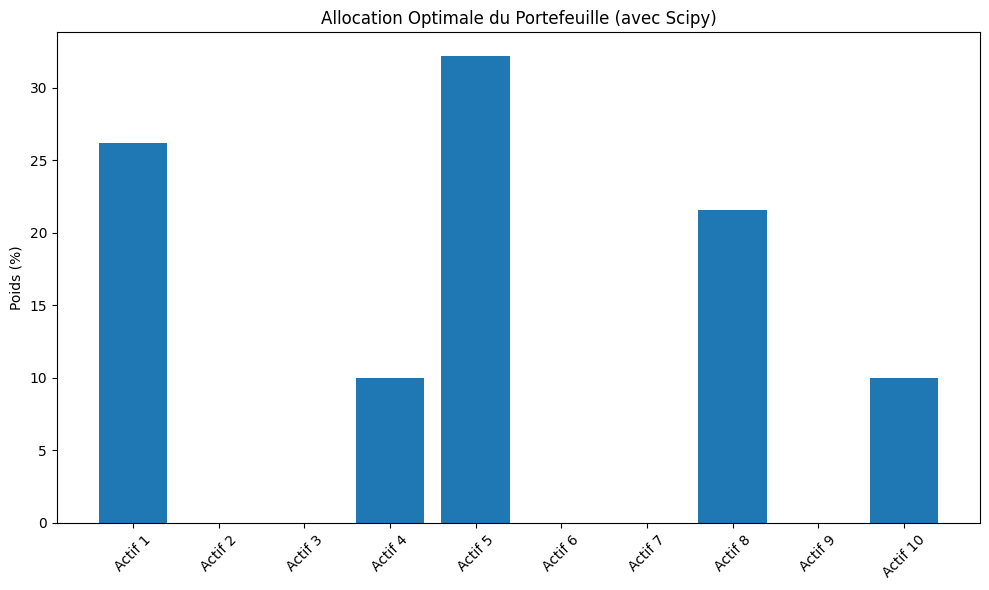

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from itertools import combinations

# --- 1. Paramètres et Données de Marché Simulées ---
n = 10
np.random.seed(0)
mu = np.abs(np.random.randn(n)) / 10
Sigma = np.random.randn(n, n)
Sigma = Sigma.T @ Sigma / 10

R_target = 0.05
K_max = 5
w_min = 0.10
risk_free_rate = 0.02

# --- Visualisation du profil Risque/Rendement des actifs ---
volatilities = np.sqrt(np.diag(Sigma))
plt.figure(figsize=(12, 7))

sharpe_levels = np.array([0.01, 0.05, 0.1, 0.2, 0.3])
vol_grid = np.linspace(0, np.max(volatilities) * 1.1, 100)
for sr in sharpe_levels:
    return_grid = risk_free_rate + sr * vol_grid
    plt.plot(vol_grid * 100, return_grid * 100, '--', label=f'Sharpe Ratio = {sr:.1f}')

plt.scatter(volatilities * 100, mu * 100, s=100, c='red', zorder=5)
for i in range(n):
    plt.text(volatilities[i] * 100 + 0.2, mu[i] * 100, f'Actif {i+1}')

plt.title("Profil Risque/Rendement et Lignes d'Iso-Sharpe Ratio")
plt.xlabel("Volatilité (Risque, en %)")
plt.ylabel("Rendement Attendu (en %)")
plt.grid(True)
plt.legend()
plt.xlim(0, np.max(volatilities) * 100 * 1.1)
plt.ylim(bottom=0)
plt.show()

# --- Calcul pour un portefeuille à poids égaux (1/N) ---
print("--- Analyse du Portefeuille de Référence (Poids Égaux 1/N) ---")
w_equal = np.full(n, 1/n)
equal_return = w_equal.T @ mu
equal_risk = np.sqrt(w_equal.T @ Sigma @ w_equal)
equal_sharpe = (equal_return - risk_free_rate) / equal_risk # <-- AJOUT
print(f"Rendement attendu : {equal_return*100:.2f}%")
print(f"Risque/Volatilité : {equal_risk*100:.2f}%")
print(f"Sharpe Ratio      : {equal_sharpe:.2f}") # <-- AJOUT
print("-" * 50)

# --- Méthode de sélection par Sharpe Ratio ---
print("--- Analyse du Portefeuille (Sélection par Sharpe Ratio) ---")
excess_returns = mu - risk_free_rate
sharpe_ratios = excess_returns / volatilities
top_indices = np.argsort(sharpe_ratios)[-K_max:]
w_sharpe = np.zeros(n)
w_sharpe[top_indices] = 1 / K_max
sharpe_return = w_sharpe.T @ mu
sharpe_risk = np.sqrt(w_sharpe.T @ Sigma @ w_sharpe)
sharpe_portfolio_sharpe = (sharpe_return - risk_free_rate) / sharpe_risk # <-- AJOUT
print(f"Actifs sélectionnés : {[f'Actif {i+1}' for i in top_indices]}")
print(f"Rendement attendu : {sharpe_return*100:.2f}%")
print(f"Risque/Volatilité : {sharpe_risk*100:.2f}%")
print(f"Sharpe Ratio      : {sharpe_portfolio_sharpe:.2f}") # <-- AJOUT
print("-" * 50)

# --- Stratégie d'Optimisation ---
def portfolio_variance(w, Sigma):
    return w.T @ Sigma @ w

best_risk = np.inf
best_weights_subset = None
best_combination = None

asset_indices = list(range(n))
for combo in combinations(asset_indices, K_max):
    combo_indices = list(combo)
    mu_subset = mu[combo_indices]
    Sigma_subset = Sigma[np.ix_(combo_indices, combo_indices)]

    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w.T @ mu_subset - R_target})

    bounds = tuple((w_min, 1.0) for _ in range(K_max))
    w_init = np.full(K_max, 1 / K_max)

    result = minimize(portfolio_variance, w_init, args=(Sigma_subset,),
                      method='SLSQP', bounds=bounds, constraints=cons)

    if result.success:
        current_risk = result.fun
        if current_risk < best_risk:
            best_risk = current_risk
            best_weights_subset = result.x
            best_combination = combo_indices

# --- Reconstitution et Analyse des Résultats ---
print("\n--- Portefeuille Optimal Construit (avec Scipy) ---")

w_optimal = np.zeros(n)
if best_combination is not None:
    w_optimal[best_combination] = best_weights_subset
    assets = [f'Actif {i+1}' for i in range(n)]
    for i, weight in enumerate(w_optimal):
        if weight > 1e-6:
            print(f"{assets[i]}: {weight*100:.2f}%")

    num_assets = np.sum(w_optimal > 1e-6)
    print(f"\nNombre d'actifs dans le portefeuille : {num_assets}")
    portfolio_return = w_optimal.T @ mu
    portfolio_risk = np.sqrt(best_risk)
    optimal_sharpe = (portfolio_return - risk_free_rate) / portfolio_risk # <-- AJOUT

    print(f"Rendement attendu : {portfolio_return*100:.2f}%")
    print(f"Risque (écart-type) : {portfolio_risk*100:.2f}%")
    print(f"Sharpe Ratio      : {optimal_sharpe:.2f}") # <-- AJOUT

    plt.figure(figsize=(10, 6))
    plt.bar(assets, w_optimal * 100)
    plt.title("Allocation Optimale du Portefeuille (avec Scipy)")
    plt.ylabel("Poids (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune solution optimale n'a été trouvée.")

<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:64: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3139797297.py:64: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t, W_merton, label=f"Stratégie Optimale (Merton, $\pi$={pi_merton:.0%})")
/tmp/ipython-input-3139797297.py:65: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(t, W_static, label=f"Stratégie Statique ($\pi$={pi_static:.0%})")


--- Stratégie de Contrôle Stochastique (Merton) ---
Fraction optimale à allouer à l'actif risqué : 83.33%


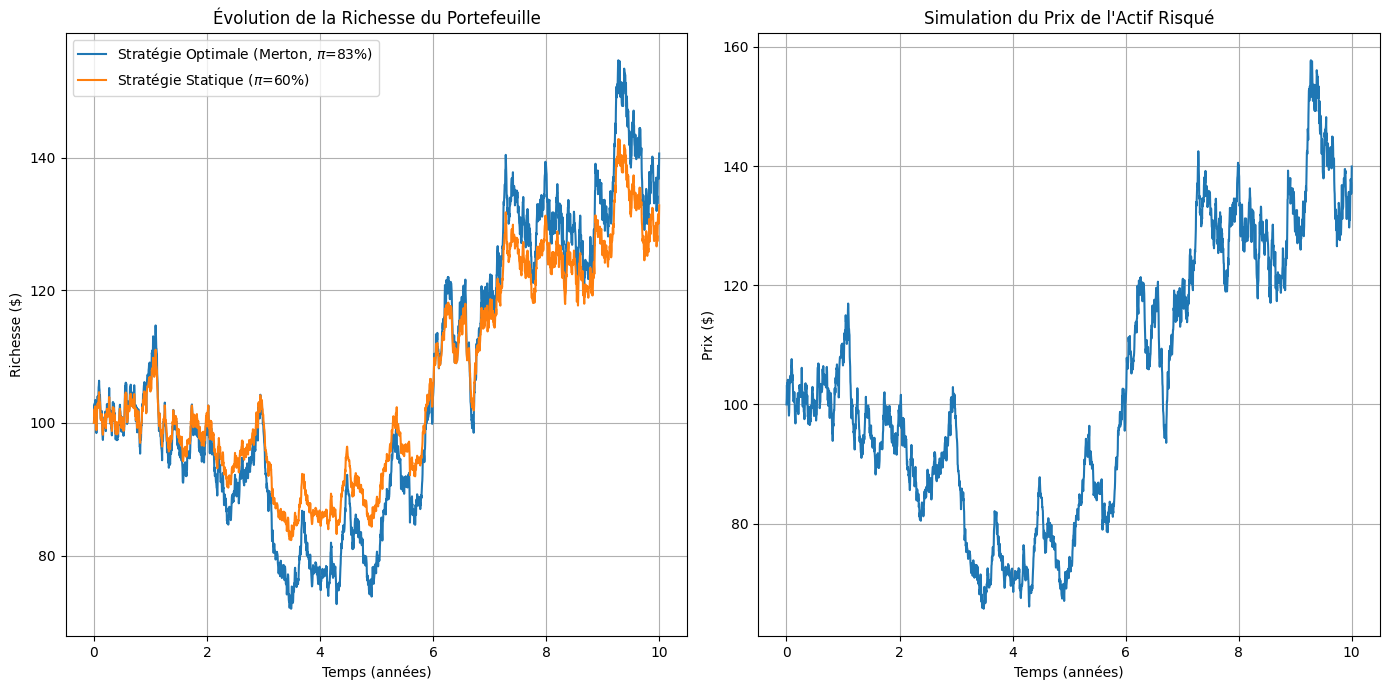


--- Résultats Finaux ---
Richesse finale (Stratégie Merton) : $140.63
Richesse finale (Stratégie Statique) : $132.81


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres du modèle ---
# Paramètres de marché
mu = 0.12     # Rendement attendu de l'actif risqué (12%)
sigma = 0.20  # Volatilité de l'actif risqué (20%)
r = 0.02      # Taux d'intérêt sans risque (5%)

# Paramètres de l'investisseur
gamma = 3.0   # Coefficient d'aversion au risque
W0 = 100      # Richesse initiale

# Paramètres de la simulation
T = 10.0      # Horizon de temps en années
N = 252 * T   # Nombre de pas de temps (jours de trading)
dt = T / N    # Intervalle de temps

# --- 2. Calcul de la stratégie optimale de Merton ---
pi_merton = (mu - r) / (gamma * sigma**2)
print(f"--- Stratégie de Contrôle Stochastique (Merton) ---")
print(f"Fraction optimale à allouer à l'actif risqué : {pi_merton:.2%}")

# --- 3. Simulation des trajectoires ---

# Initialisation des tableaux pour stocker les résultats
t = np.linspace(0, T, int(N) + 1)
S = np.zeros(int(N) + 1)
W_merton = np.zeros(int(N) + 1)
W_static = np.zeros(int(N) + 1) # Portefeuille de comparaison statique (60/40)

# Conditions initiales
S[0] = 100
W_merton[0] = W0
W_static[0] = W0

# Génération des chocs aléatoires
Z = np.random.randn(int(N) + 1)

# Stratégie statique de comparaison (ex: 60% actions)
pi_static = 0.60
amount_static_risky = W0 * pi_static
amount_static_riskless = W0 * (1 - pi_static)
shares_static_risky = amount_static_risky / S[0]

for i in range(1, int(N) + 1):
    # Simulation du prix de l'actif risqué (Mouvement Brownien Géométrique)
    S[i] = S[i-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[i])

    # --- Évolution du portefeuille de Merton (rééquilibrage continu) ---
    # La richesse évolue en fonction de la performance de chaque partie
    W_merton[i] = W_merton[i-1] * (pi_merton * (S[i] - S[i-1]) / S[i-1] + (1 - pi_merton) * r * dt + 1)

    # --- Évolution du portefeuille statique (acheter et conserver) ---
    # Le nombre d'actions reste fixe, seul le montant en cash évolue au taux r
    amount_static_riskless *= (1 + r * dt)
    W_static[i] = shares_static_risky * S[i] + amount_static_riskless

# --- 4. Visualisation ---
plt.figure(figsize=(14, 7))

# Graphique 1 : Évolution de la richesse
plt.subplot(1, 2, 1)
plt.plot(t, W_merton, label=f"Stratégie Optimale (Merton, $\pi$={pi_merton:.0%})")
plt.plot(t, W_static, label=f"Stratégie Statique ($\pi$={pi_static:.0%})")
plt.title("Évolution de la Richesse du Portefeuille")
plt.xlabel("Temps (années)")
plt.ylabel("Richesse ($)")
plt.grid(True)
plt.legend()

# Graphique 2 : Trajectoire du prix de l'actif risqué
plt.subplot(1, 2, 2)
plt.plot(t, S)
plt.title("Simulation du Prix de l'Actif Risqué")
plt.xlabel("Temps (années)")
plt.ylabel("Prix ($)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Affichage des résultats finaux
print("\n--- Résultats Finaux ---")
print(f"Richesse finale (Stratégie Merton) : ${W_merton[-1]:.2f}")
print(f"Richesse finale (Stratégie Statique) : ${W_static[-1]:.2f}")

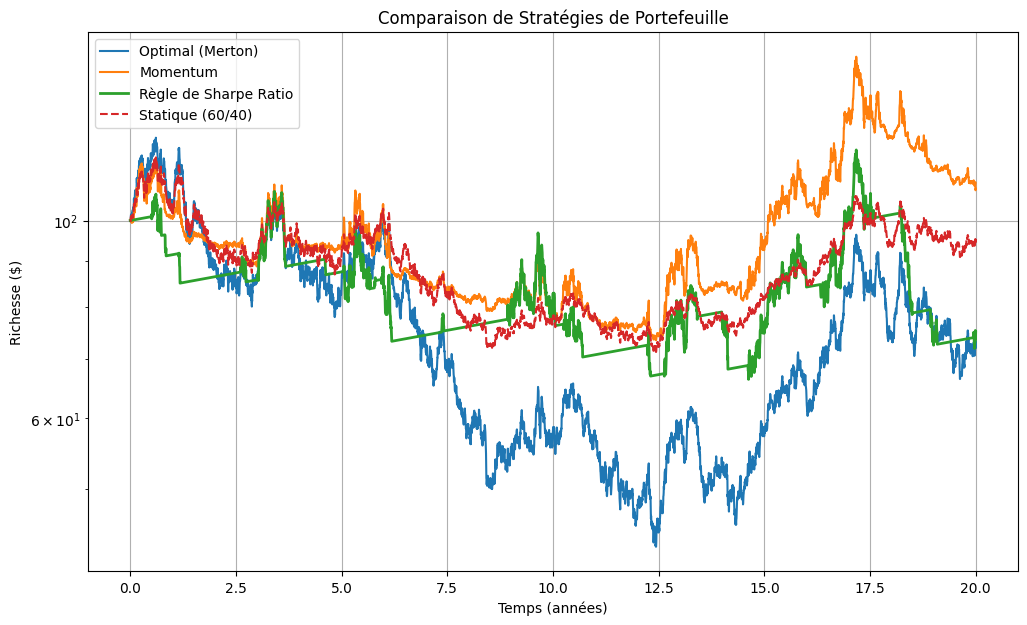

--- Résultats Finaux ---
Stratégie                 | Richesse Finale |  Rendement Ann. | Volatilité Ann. |    Sharpe Ratio
------------------------------------------------------------------------------------------
Optimal (Merton)          | $         73.06 |         -1.56% |         16.76% |           -0.21
Momentum                  | $        108.57 |          0.41% |         12.13% |           -0.13
Règle de Sharpe Ratio     | $         74.98 |         -1.43% |         12.80% |           -0.27
Statique (60/40)          | $         95.20 |         -0.25% |          8.95% |           -0.25


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Paramètres ---
mu = 0.12
sigma = 0.20
r = 0.02
W0 = 100
T = 20.0
gamma = 3.0
risk_free_rate = r

# Paramètres pour la stratégie Momentum
pi_momentum_high = 0.90
pi_momentum_low = 0.20
moving_average_window = 252

# Paramètres pour la stratégie Sharpe Ratio Rule
sharpe_window = 126
sharpe_buy_threshold = 0.3
sharpe_sell_threshold = -0.3

# Simulation
N = int(252 * T)
dt = T / N
t = np.linspace(0, T, N + 1)

# --- 2. Simulation des 4 Stratégies ---

# Initialisation
S = np.zeros(N + 1)
W_merton = np.zeros(N + 1)
W_static = np.zeros(N + 1)
W_momentum = np.zeros(N + 1)
W_sharpe_rule = np.zeros(N + 1)

S[0] = 100
W_merton[0], W_static[0], W_momentum[0], W_sharpe_rule[0] = W0, W0, W0, W0
Z = np.random.randn(N + 1)

# Allocation statique 60/40
pi_static = 0.60
shares_static_risky = (W0 * pi_static) / S[0]
amount_static_riskless = W0 * (1 - pi_static)

# Variables pour la stratégie Sharpe (pour conserver la position et la valeur cash)
pi_sharpe_rule = 0.0
sharpe_cash_value = W0

for i in range(1, N + 1):
    # Simulation du prix de l'actif
    S[i] = S[i-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[i])
    risky_return = (S[i] - S[i-1]) / S[i-1]
    riskless_return = r * dt

    # --- Stratégie 1 : Merton (Contrôle Optimal) ---
    pi_merton = (mu - r) / (gamma * sigma**2)
    merton_return = pi_merton * risky_return + (1 - pi_merton) * riskless_return
    W_merton[i] = W_merton[i-1] * (1 + merton_return)

    # --- Stratégie 2 : Statique (Acheter et Conserver) ---
    amount_static_riskless *= (1 + riskless_return)
    W_static[i] = shares_static_risky * S[i] + amount_static_riskless

    # --- Stratégie 3 : Momentum (Suivi de Tendance) ---
    start_index = max(0, i - moving_average_window)
    moving_avg = S[start_index:i].mean()
    pi_momentum = pi_momentum_high if S[i-1] > moving_avg else pi_momentum_low
    momentum_return = pi_momentum * risky_return + (1 - pi_momentum) * riskless_return
    W_momentum[i] = W_momentum[i-1] * (1 + momentum_return)

    # --- Stratégie 4 : Règle de Sharpe Ratio (LOGIQUE CORRIGÉE) ---
    old_pi_sharpe = pi_sharpe_rule
    if i > sharpe_window:
        window_returns = pd.Series(S[i-sharpe_window:i]).pct_change().dropna()
        # S'assurer qu'on a assez de données pour std()
        if len(window_returns) > 1:
            excess_returns = window_returns - (r * dt)
            rolling_sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)
            if rolling_sharpe > sharpe_buy_threshold:
                pi_sharpe_rule = 1.0 # Acheter (100% alloué)
            elif rolling_sharpe < sharpe_sell_threshold:
                pi_sharpe_rule = 0.0 # Vendre (0% alloué)

    # Si on vient de vendre (passe de 1 à 0), on stocke la valeur en cash
    if old_pi_sharpe == 1.0 and pi_sharpe_rule == 0.0:
        sharpe_cash_value = W_sharpe_rule[i-1]

    # Si on est investi (pi=1), la richesse suit le rendement de l'actif
    if pi_sharpe_rule == 1.0:
        # Si on vient de racheter (passe de 0 à 1), on repart de la valeur cash
        if old_pi_sharpe == 0.0:
            W_sharpe_rule[i] = sharpe_cash_value * (1 + risky_return)
        else:
            W_sharpe_rule[i] = W_sharpe_rule[i-1] * (1 + risky_return)
    # Si on est désinvesti (pi=0), la richesse croît au taux sans risque
    else:
        # On utilise la valeur cash stockée pour la croissance
        sharpe_cash_value *= (1 + riskless_return)
        W_sharpe_rule[i] = sharpe_cash_value


# --- 3. Visualisation ---
plt.figure(figsize=(12, 7))
plt.plot(t, W_merton, label=f"Optimal (Merton)")
plt.plot(t, W_momentum, label=f"Momentum")
plt.plot(t, W_sharpe_rule, label=f"Règle de Sharpe Ratio", linewidth=2)
plt.plot(t, W_static, label=f"Statique (60/40)", linestyle='--')
plt.title("Comparaison de Stratégies de Portefeuille")
plt.xlabel("Temps (années)")
plt.ylabel("Richesse ($)")
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

# --- 4. Calcul des Métriques de Performance Finales ---
def calculate_performance_metrics(wealth_series, T, risk_free_rate):
    daily_returns = pd.Series(wealth_series).pct_change().dropna()
    total_return = (wealth_series[-1] / wealth_series[0]) - 1
    annualized_return = (1 + total_return)**(1/T) - 1
    annualized_volatility = daily_returns.std() * np.sqrt(252)
    if annualized_volatility == 0: # Éviter la division par zéro
        sharpe_ratio = np.inf
    else:
        sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility
    return annualized_return, annualized_volatility, sharpe_ratio

merton_ret, merton_vol, merton_sharpe = calculate_performance_metrics(W_merton, T, risk_free_rate)
momentum_ret, momentum_vol, momentum_sharpe = calculate_performance_metrics(W_momentum, T, risk_free_rate)
sharpe_rule_ret, sharpe_rule_vol, sharpe_rule_sharpe = calculate_performance_metrics(W_sharpe_rule, T, risk_free_rate)
static_ret, static_vol, static_sharpe = calculate_performance_metrics(W_static, T, risk_free_rate)

# --- 5. Résultats Finaux ---
print("--- Résultats Finaux ---")
print(f"{'Stratégie':<25} | {'Richesse Finale':>15} | {'Rendement Ann.':>15} | {'Volatilité Ann.':>15} | {'Sharpe Ratio':>15}")
print("-" * 90)
print(f"{'Optimal (Merton)':<25} | ${W_merton[-1]:>14.2f} | {merton_ret:>14.2%} | {merton_vol:>14.2%} | {merton_sharpe:>15.2f}")
print(f"{'Momentum':<25} | ${W_momentum[-1]:>14.2f} | {momentum_ret:>14.2%} | {momentum_vol:>14.2%} | {momentum_sharpe:>15.2f}")
print(f"{'Règle de Sharpe Ratio':<25} | ${W_sharpe_rule[-1]:>14.2f} | {sharpe_rule_ret:>14.2%} | {sharpe_rule_vol:>14.2%} | {sharpe_rule_sharpe:>15.2f}")
print(f"{'Statique (60/40)':<25} | ${W_static[-1]:>14.2f} | {static_ret:>14.2%} | {static_vol:>14.2%} | {static_sharpe:>15.2f}")

In [ ]:
'''
Insider Trading Project

Form 4 Insider Data Download Tool
'''
import requests
import pandas as pd
import time
import os
from google.colab import drive

# --- 1. Configuration ---
drive.mount('/content/drive')
HEADERS = {'User-Agent': 'Mon Projet Quant/Mon Nom prenom.nom@email.com'}
DATA_DIR = '/content/drive/MyDrive/Colab_Data/sec_data_xml'
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

# --- 2. Fonctions de Récupération (Logique de téléchargement corrigée) ---

def get_ticker_to_cik_map():
    """Télécharge la table de correspondance Ticker -> CIK."""
    print("Téléchargement de la table de correspondance Ticker <-> CIK...")
    try:
        response = requests.get('https://www.sec.gov/files/company_tickers.json', headers=HEADERS)
        response.raise_for_status()
        company_data = response.json()
        ticker_to_cik = {item['ticker']: str(item['cik_str']).zfill(10) for item in company_data.values()}
        print("Table téléchargée.")
        return ticker_to_cik
    except requests.exceptions.RequestException as e:
        print(f"Erreur lors du téléchargement de la table Ticker/CIK : {e}")
        return None

def get_recent_form4_filings(cik):
    """Récupère les métadonnées des dépôts récents pour un CIK et filtre pour les Form 4."""
    url = f"https://data.sec.gov/submissions/CIK{cik}.json"
    print(f"Récupération des dépôts pour le CIK : {cik}...")
    try:
        response = requests.get(url, headers=HEADERS)
        response.raise_for_status()
        submissions = response.json()
        recent_filings = pd.DataFrame(submissions['filings']['recent'])
        form4_filings = recent_filings[recent_filings['form'] == '4']
        print(f"Trouvé {len(form4_filings)} dépôts de Form 4 récents.")
        return form4_filings
    except (requests.exceptions.RequestException, KeyError) as e:
        print(f"Erreur ou aucun dépôt trouvé pour le CIK {cik} : {e}")
        return pd.DataFrame()

# --- FONCTION CORRIGÉE ---
def download_filing(cik, accession_number, primary_document):
    """
    Télécharge le document de dépôt principal en utilisant son nom exact.
    Ne télécharge que s'il s'agit d'un fichier .xml.
    """
    if not primary_document.lower().endswith('.xml'):
        print(f"Document ignoré (n'est pas un XML) : {primary_document}")
        return

    url_accession_number = accession_number.replace('-', '')
    url = f"https://www.sec.gov/Archives/edgar/data/{cik}/{url_accession_number}/{primary_document}"
    save_path = os.path.join(DATA_DIR, f"{cik}-{accession_number}.xml")

    print(f"Téléchargement du fichier XML : {primary_document}...")
    try:
        response = requests.get(url, headers=HEADERS)
        response.raise_for_status()

        with open(save_path, 'w', encoding='utf-8') as f:
            f.write(response.text)
        print(f"Fichier XML sauvegardé dans : {save_path}")

    except requests.exceptions.RequestException as e:
        print(f"Erreur lors du téléchargement du document {accession_number} : {e}")

# --- 3. Script Principal ---

if __name__ == "__main__":
    ticker_cik_map = get_ticker_to_cik_map()

    if ticker_cik_map:
        tickers_to_track = ['AAPL', 'MSFT', 'NVDA', 'TSLA']

        for ticker in tickers_to_track:
            cik = ticker_cik_map.get(ticker)
            if not cik:
                print(f"Ticker {ticker} non trouvé.")
                continue

            print(f"\n--- Traitement de {ticker} (CIK: {cik}) ---")
            recent_forms = get_recent_form4_filings(cik)

            if not recent_forms.empty:
                # --- APPEL CORRIGÉ ---
                for index, row in recent_forms.iterrows():
                    download_filing(cik, row['accessionNumber'], row['primaryDocument'])
                    time.sleep(0.2) # Respecter la limite de la SEC

            print(f"--- Fin du traitement pour {ticker} ---")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Téléchargement de la table de correspondance Ticker <-> CIK...
Table téléchargée.

--- Traitement de AAPL (CIK: 0000320193) ---
Récupération des dépôts pour le CIK : 0000320193...
Trouvé 590 dépôts de Form 4 récents.
Téléchargement du fichier XML : xslF345X05/wk-form4_1759530830.xml...
Fichier XML sauvegardé dans : /content/drive/MyDrive/Colab_Data/sec_data_xml/0000320193-0001214156-25-000011.xml
Téléchargement du fichier XML : xslF345X05/wk-form4_1759530744.xml...
Fichier XML sauvegardé dans : /content/drive/MyDrive/Colab_Data/sec_data_xml/0000320193-0001767094-25-000009.xml
Téléchargement du fichier XML : xslF345X05/wk-form4_1759530690.xml...
Fichier XML sauvegardé dans : /content/drive/MyDrive/Colab_Data/sec_data_xml/0000320193-0002078476-25-000005.xml
Téléchargement du fichier XML : xslF345X05/wk-form4_1759530624.xml...
Fichier XML sauvegardé dans : /cont

In [ ]:
import requests
import pandas as pd
import time
import os
from google.colab import drive

# --- 1. Configuration ---
drive.mount('/content/drive')
HEADERS = {'User-Agent': 'Mon Projet Quant/Louis GAY miraca742@gmail.com'}
DATA_DIR = '/content/drive/MyDrive/Colab_Data/sec_data_xml'
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

# --- 2. Fonctions de Récupération (Logique de téléchargement corrigée) ---

def get_ticker_to_cik_map():
    """Télécharge la table de correspondance Ticker -> CIK."""
    print("Téléchargement de la table de correspondance Ticker <-> CIK...")
    try:
        response = requests.get('https://www.sec.gov/files/company_tickers.json', headers=HEADERS)
        response.raise_for_status()
        company_data = response.json()
        ticker_to_cik = {item['ticker']: str(item['cik_str']).zfill(10) for item in company_data.values()}
        print("Table téléchargée.")
        return ticker_to_cik
    except requests.exceptions.RequestException as e:
        print(f"Erreur lors du téléchargement de la table Ticker/CIK : {e}")
        return None

def get_recent_form4_filings(cik):
    """Récupère les métadonnées des dépôts récents pour un CIK et filtre pour les Form 4."""
    url = f"https://data.sec.gov/submissions/CIK{cik}.json"
    print(f"Récupération des dépôts pour le CIK : {cik}...")
    try:
        response = requests.get(url, headers=HEADERS)
        response.raise_for_status()
        submissions = response.json()
        recent_filings = pd.DataFrame(submissions['filings']['recent'])
        form4_filings = recent_filings[recent_filings['form'] == '4']
        print(f"Trouvé {len(form4_filings)} dépôts de Form 4 récents.")
        return form4_filings
    except (requests.exceptions.RequestException, KeyError) as e:
        print(f"Erreur ou aucun dépôt trouvé pour le CIK {cik} : {e}")
        return pd.DataFrame()

# --- FONCTION CORRIGÉE ---
def download_filing(cik, accession_number, primary_document):
    """
    Télécharge le document de dépôt principal en utilisant son nom exact.
    Ne télécharge que s'il s'agit d'un fichier .xml.
    """
    if not primary_document.lower().endswith('.xml'):
        print(f"Document ignoré (n'est pas un XML) : {primary_document}")
        return

    url_accession_number = accession_number.replace('-', '')
    url = f"https://www.sec.gov/Archives/edgar/data/{cik}/{url_accession_number}/{primary_document}"
    save_path = os.path.join(DATA_DIR, f"{cik}-{accession_number}.xml")

    print(f"Téléchargement du fichier XML : {primary_document}...")
    try:
        response = requests.get(url, headers=HEADERS)
        response.raise_for_status()

        with open(save_path, 'w', encoding='utf-8') as f:
            f.write(response.text)
        print(f"Fichier XML sauvegardé dans : {save_path}")

    except requests.exceptions.RequestException as e:
        print(f"Erreur lors du téléchargement du document {accession_number} : {e}")

# --- 3. Script Principal ---

if __name__ == "__main__":
    ticker_cik_map = get_ticker_to_cik_map()

    if ticker_cik_map:
        tickers_to_track = ['AAPL', 'MSFT', 'NVDA', 'TSLA']

        for ticker in tickers_to_track:
            cik = ticker_cik_map.get(ticker)
            if not cik:
                print(f"Ticker {ticker} non trouvé.")
                continue

            print(f"\n--- Traitement de {ticker} (CIK: {cik}) ---")
            recent_forms = get_recent_form4_filings(cik)

            if not recent_forms.empty:
                # --- APPEL CORRIGÉ ---
                for index, row in recent_forms.iterrows():
                    download_filing(cik, row['accessionNumber'], row['primaryDocument'])
                    time.sleep(0.2) # Respecter la limite de la SEC

            print(f"--- Fin du traitement pour {ticker} ---")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Téléchargement de la table de correspondance Ticker <-> CIK...
Table téléchargée.

--- Traitement de AAPL (CIK: 0000320193) ---
Récupération des dépôts pour le CIK : 0000320193...
Trouvé 590 dépôts de Form 4 récents.
Téléchargement du fichier XML : xslF345X05/wk-form4_1759530830.xml...
Fichier XML sauvegardé dans : /content/drive/MyDrive/Colab_Data/sec_data_xml/0000320193-0001214156-25-000011.xml
Téléchargement du fichier XML : xslF345X05/wk-form4_1759530744.xml...
Fichier XML sauvegardé dans : /content/drive/MyDrive/Colab_Data/sec_data_xml/0000320193-0001767094-25-000009.xml
Téléchargement du fichier XML : xslF345X05/wk-form4_1759530690.xml...
Fichier XML sauvegardé dans : /content/drive/MyDrive/Colab_Data/sec_data_xml/0000320193-0002078476-25-000005.xml
Téléchargement du fichier XML : xslF345X05/wk-form4_1759530624.xml...
Fichier XML sauvegardé dans : /cont

Téléchargement des données de l'EUR/USD...


/tmp/ipython-input-3264100553.py:57: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('EURUSD=X', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed


Calcul de l'exposant de Hurst glissant (lookback de 256 jours)...


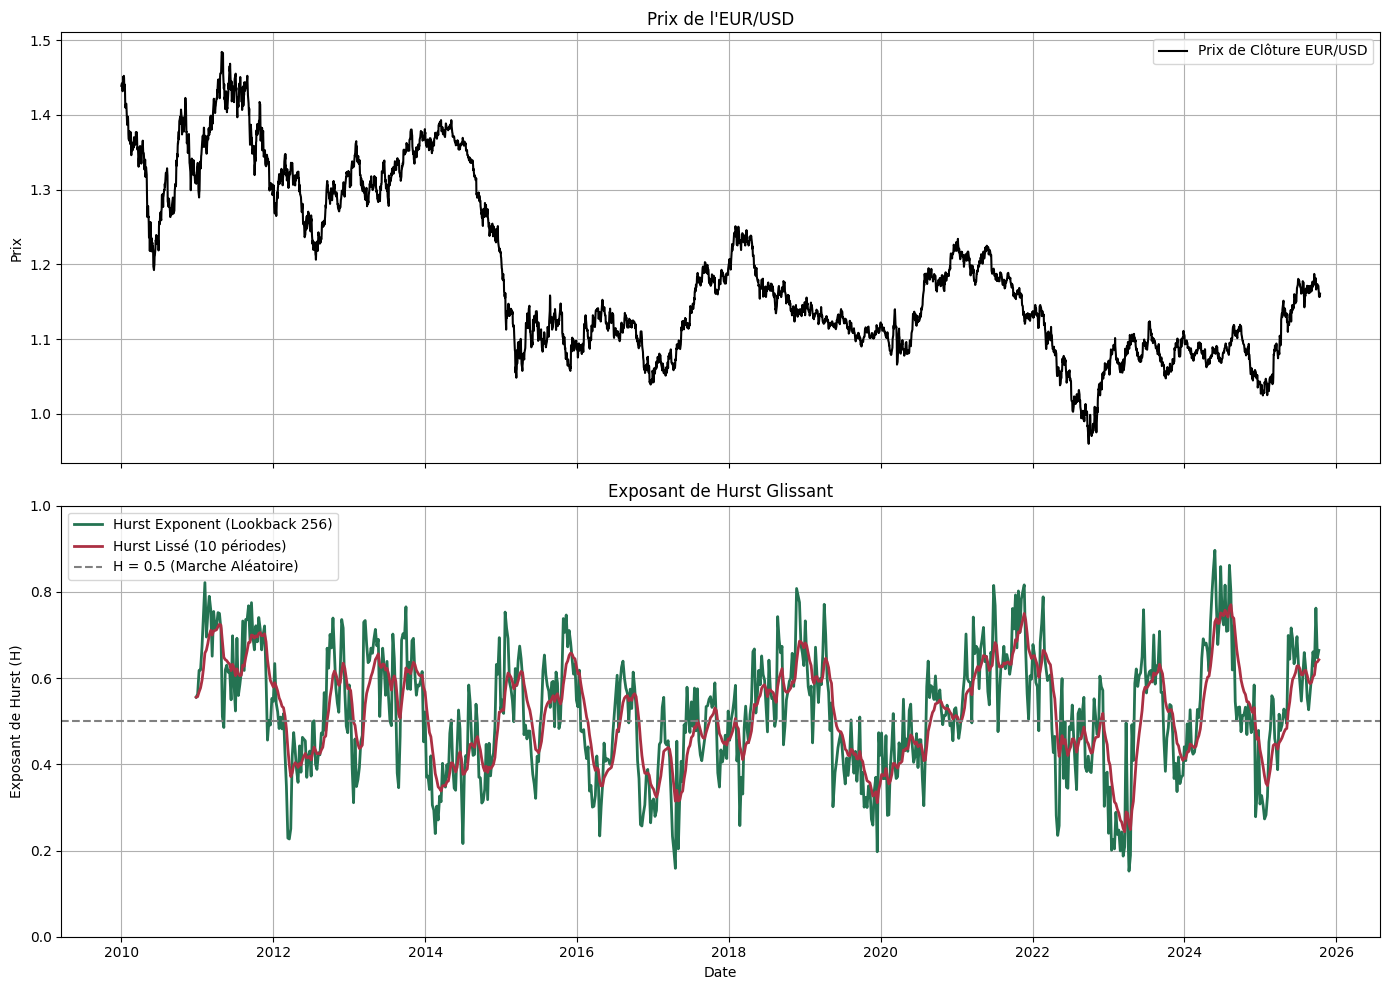


La valeur la plus récente de l'exposant de Hurst est : 0.6642


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_hurst_exponent(series_values, lookback):
    """
    Calcule l'exposant de Hurst en utilisant des arrays NumPy pour la performance.
    """
    sample_sizes = [32, 64, 128, 256, 512]
    sample_sizes = [s for s in sample_sizes if s < lookback]
    if len(sample_sizes) < 2:
        return np.nan

    # Créer les rendements à partir des valeurs brutes
    pnl = np.log(series_values[1:] / series_values[:-1])

    log_rs_values = []
    log_n_values = []

    for group_len in sample_sizes:
        rs_values_for_group = []
        num_groups = int(np.floor(len(pnl) / group_len))

        for group in range(num_groups):
            start = group * group_len
            end = start + group_len
            chunk = pnl[start:end]

            if len(chunk) < 2:
                continue

            mean = np.mean(chunk)
            std_dev = np.std(chunk)

            if std_dev == 0:
                continue

            cumulative_series = np.cumsum(chunk - mean)
            R = np.max(cumulative_series) - np.min(cumulative_series)
            rs_values_for_group.append(R / std_dev)

        if rs_values_for_group:
            avg_rs = np.mean(rs_values_for_group)
            log_rs_values.append(np.log(avg_rs))
            log_n_values.append(np.log(group_len))

    if len(log_rs_values) < 2:
        return np.nan

    hurst_exponent = np.polyfit(log_n_values, log_rs_values, 1)[0]
    return hurst_exponent

# --- Script Principal ---
if __name__ == "__main__":
    print("Téléchargement des données de l'EUR/USD...")
    data = yf.download('EURUSD=X', start='2010-01-01')
    prices = data['Close'].dropna()

    lookback = 256
    step_size = 5
    print(f"Calcul de l'exposant de Hurst glissant (lookback de {lookback} jours)...")

    hurst_values = []
    hurst_dates = []

    for i in range(lookback, len(prices), step_size):
        # Passer les valeurs NumPy (.values) à la fonction
        window_prices = prices.iloc[i - lookback : i].values
        H = get_hurst_exponent(window_prices, lookback)

        if not np.isnan(H):
            hurst_values.append(H)
            hurst_dates.append(prices.index[i])

    rolling_hurst = pd.Series(data=hurst_values, index=hurst_dates)
    smoothed_hurst = rolling_hurst.ewm(span=10, adjust=False).mean()

    # Visualisation
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    ax1.plot(prices.index, prices, label='Prix de Clôture EUR/USD', color='black')
    ax1.set_title('Prix de l\'EUR/USD')
    ax1.set_ylabel('Prix')
    ax1.grid(True)
    ax1.legend()

    ax2.plot(rolling_hurst.index, rolling_hurst, label=f'Hurst Exponent (Lookback {lookback})', color='#247352', linewidth=2)
    ax2.plot(smoothed_hurst.index, smoothed_hurst, label=f'Hurst Lissé (10 périodes)', color='#ab3043', linewidth=2)
    ax2.axhline(0.5, color='gray', linestyle='--', label='H = 0.5 (Marche Aléatoire)')

    ax2.set_title('Exposant de Hurst Glissant')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Exposant de Hurst (H)')
    ax2.set_ylim(0, 1)
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    latest_hurst = rolling_hurst.iloc[-1]
    print(f"\nLa valeur la plus récente de l'exposant de Hurst est : {latest_hurst:.4f}")